# <span style="color: #51e2f5;"> Plant Disease Classification - Capstone Project </span>

**Author:** Rangarajan Ramachandran  
**Date:** February 2026  
**Dataset:** PlantVillage (38 classes)

## <span style="color: #9df9ef;">Problem Statement</span>

Plant disease is a common cause of plant loss and unnecessary expense for home gardeners and small-scale growers, largely due to the difficulty of accurately identifying diseases based on visual symptoms alone. Many plant diseases exhibit similar leaf patterns, making correct diagnosis challenging without expert knowledge, which leads to delayed action or ineffective treatments. This project addresses the problem by developing an image-based machine learning system capable of identifying common plant diseases from photographs of plant leaves and translating those predictions into actionable decision support. By enabling faster and more reliable disease identification, the proposed solution aims to reduce guesswork, improve plant health outcomes, and demonstrate how artificial intelligence can be applied as a practical decision-support tool for non-technical users.

## <span style="color: #9df9ef;">1. Understanding the Data</span>

### <span style="color: #edf756;">1.1 What is the PlantVillage Dataset?</span>

The **PlantVillage dataset** is a widely-used benchmark dataset in agricultural AI research, containing high-resolution images of plant leaves categorized by plant species and disease type. Originally developed to enable automated plant disease detection, this dataset has become a cornerstone for computer vision research in agriculture.

**Key Characteristics:**
- **Size:** Over 54,000 images of plant leaves
- **Classes:** 38 distinct categories representing different plant-disease combinations
- **Plants covered:** 14 crop species including tomato, potato, pepper, corn, apple, cherry, grape, peach, and more
- **Image conditions:** Images captured under controlled laboratory conditions with uniform backgrounds
- **Format:** RGB color images, typically 256×256 pixels
- **Class structure:** Named as `PlantSpecies___DiseaseName` (e.g., `Tomato___Early_blight`)

### <span style="color: #edf756;"> 1.2 Understanding Plant Diseases </span>

Plant diseases pose significant challenges to agriculture, causing substantial crop losses worldwide. The diseases in this dataset represent common afflictions that gardeners and farmers encounter:

**Disease Categories:**

1. **Fungal Diseases** (Most common in dataset)
   - *Early blight* - Circular brown spots with concentric rings
   - *Late blight* - Dark, water-soaked lesions
   - *Leaf spot* - Small spots that may merge into larger lesions
   - *Powdery mildew* - White, powdery coating on leaves
   - *Rust* - Orange-brown pustules
   
2. **Bacterial Diseases**
   - *Bacterial spot* - Small, dark spots with yellow halos
   - *Bacterial canker* - Wilting and lesions
   
3. **Viral Diseases**
   - *Mosaic virus* - Mottled yellow-green patterns
   - *Leaf curl* - Distorted, curled leaves
   
4. **Healthy Leaves**
   - Normal, disease-free plant leaves for comparison

### <span style="color: #edf756;"> 1.3 Why Visual Classification is Challenging </span>

Plant disease identification from images presents unique challenges:

**1. Visual Similarity**
- Different diseases may produce similar symptoms (e.g., various leaf spots)
- Early stages of different diseases can look nearly identical
- Color variations due to disease severity can be subtle

**2. Within-Class Variation**
- Same disease may appear differently on different leaf parts
- Disease progression creates varying visual presentations
- Environmental factors affect symptom appearance

**3. Image Acquisition Factors**
- Lighting conditions affect color perception
- Camera angles and distances vary
- Leaf age and seasonal factors introduce variability


### <span style="color: #edf756;"> 1.4 What Makes This Dataset Special? </span>

**Advantages:**
- ✅ **Large scale:** Sufficient data for deep learning approaches
- ✅ **Clean labels:** Expert-verified disease classifications
- ✅ **Standardized images:** Consistent format and quality
- ✅ **Diverse diseases:** Representative sample of common plant diseases
- ✅ **Benchmark status:** Widely used, enabling comparison with other research

**Limitations:**
- ⚠️ **Controlled conditions:** Images taken in laboratory settings, not field conditions
- ⚠️ **Limited variety per class:** May not capture full disease presentation spectrum
- ⚠️ **Uniform backgrounds:** May not generalize to complex natural settings
- ⚠️ **Single leaf focus:** Doesn't show plant-level symptoms or context

### <span style="color: #edf756;"> 1.5 Data Structure and Organization </span>

The dataset follows a hierarchical directory structure:

```
PlantVillageData/
├── Apple___Apple_scab/
│   ├── image_001.jpg
│   ├── image_002.jpg
│   └── ...
├── Apple___Black_rot/
│   └── ...
├── Tomato___Early_blight/
│   └── ...
└── [38 total class folders]
```

**Naming Convention:**
- Format: `PlantName___DiseaseName`
- Three underscores (`___`) separate plant from disease
- Healthy leaves: `PlantName___healthy`

### <span style="color: #edf756;"> 1.6 Expected Class Distribution </span>

The dataset contains varying numbers of images per class, which is important for understanding potential class imbalance:

- **Most represented plants:** Tomato, Potato, Pepper
- **Least represented plants:** Orange, Soybean, Squash
- **Typical class size:** 500-5,000 images per disease category
- **Imbalance factor:** Up to 10x variation between classes

This imbalance has implications for model training and evaluation, which we'll address in preprocessing.

### <span style="color: #edf756;"> 1.7 Research Questions This Data Can Answer

Given this dataset's characteristics, we can investigate:

1. **Classification Accuracy:** How well can CNNs distinguish between disease categories?
2. **Confusion Patterns:** Which diseases are most frequently confused with each other?
3. **Plant-Specific Performance:** Do some plant species classify more accurately than others?
4. **Model Efficiency:** Can lightweight models (MobileNet) match heavy models (ResNet)?
5. **Feature Learning:** What visual patterns do models learn to identify diseases?

### <span style="color: #edf756;"> 1.8 Real-World Application Context

**Target Use Case:**
This model development aims to support:
- **Home gardeners** seeking quick disease identification
- **Small-scale farmers** without access to agricultural extension services
- **Educational platforms** teaching plant pathology
- **Mobile applications** providing on-site diagnosis

**Success Criteria:**
For practical deployment, the model should:
- Achieve >90% overall accuracy (comparable to general practitioner level)
- Minimize false negatives for severe diseases (avoid missing critical infections)
- Provide fast inference (<1 second on mobile devices)
- Offer interpretable results (show which leaf regions influenced the decision)

### <span style="color: #edf756;"> 1.9 What We'll Discover Through EDA </span>

In the following exploratory analysis, we will:

1. **Quantify class distribution** - Identify imbalance and its potential impact
2. **Visualize disease symptoms** - Understand what distinguishes each class
3. **Analyze image properties** - Verify consistency in format and quality
4. **Examine plant representation** - See which crops dominate the dataset
5. **Identify data quality issues** - Check for corrupted or mislabeled images
6. **Understand healthy/diseased ratio** - Important for baseline expectations

This understanding will inform our:
- **Preprocessing strategy** (how to handle class imbalance)
- **Model architecture selection** (complexity needed for this task)
- **Evaluation metrics** (which metrics matter most)
- **Augmentation approach** (what transformations are appropriate)

## <span style="color: #9df9ef;"> 2. Setup and Imports</span>
Installing and importing all necessary libraries for data analysis and modeling.

### <span style="color: #edf756;"> 2.1 Imports </span>

In [1]:
import os
import random
import numpy as np
import pandas as pd
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model

# Sklearn utilities
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.20.0


## <span style="color: #9df9ef;"> 3. Data Loading and Exploration </span> <a name="loading"></a>
Loading the PlantVillage dataset and performing initial exploration.

### <span style="color: #edf756;"> 3.1 Data Loading

In [ ]:
DATA_DIR = '../plantvillagedata/color'

# Verify path exists
if not os.path.exists(DATA_DIR):
    raise FileNotFoundError(f"Data directory not found: {DATA_DIR}")

print(f"Data directory: {DATA_DIR}")
print(f"Directory exists: {os.path.exists(DATA_DIR)}")

Data directory: ../plantvillagedata/color
Directory exists: True


In [3]:
# Get all class directories
class_names = sorted([d for d in os.listdir(DATA_DIR) 
                     if os.path.isdir(os.path.join(DATA_DIR, d))])

print(f"Total number of classes: {len(class_names)}")
print(f"\nFirst 5 classes:")
for i, class_name in enumerate(class_names[:5], 1):
    print(f"{i}. {class_name}")

Total number of classes: 38

First 5 classes:
1. Apple___Apple_scab
2. Apple___Black_rot
3. Apple___Cedar_apple_rust
4. Apple___healthy
5. Blueberry___healthy


In [4]:
# Count images per class
class_counts = {}
total_images = 0

for class_name in class_names:
    class_path = os.path.join(DATA_DIR, class_name)
    image_files = [f for f in os.listdir(class_path) 
                   if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    count = len(image_files)
    class_counts[class_name] = count
    total_images += count

print(f"Total images in dataset: {total_images:,}")
print(f"Average images per class: {total_images / len(class_names):.0f}")
print(f"Min images in a class: {min(class_counts.values())}")
print(f"Max images in a class: {max(class_counts.values())}")

Total images in dataset: 54,305
Average images per class: 1429
Min images in a class: 152
Max images in a class: 5507


In [5]:
counts = list(class_counts.values())
max_count = max(counts)
min_count = min(counts)
mean_count = np.mean(counts)
std_count = np.std(counts)
cv = (std_count / mean_count) * 100

print("\n" + "="*60)
print("CLASS BALANCE ANALYSIS")
print("="*60)
print(f"Largest class: {max_count:,} images")
print(f"Smallest class: {min_count:,} images")
print(f"Ratio (max/min): {max_count/min_count:.2f}x")
print(f"Mean: {mean_count:.0f} images")
print(f"Std Dev: {std_count:.0f} images")
print(f"Coefficient of Variation: {cv:.1f}%")
print("\nInterpretation:")
if cv < 20:
    print("✓ Well balanced dataset")
elif cv < 50:
    print("⚠ Moderately imbalanced - consider class weighting")
else:
    print("⚠ Highly imbalanced - requires special handling:")
    print("  - Use stratified train/val/test splits")
    print("  - Apply class weights in loss function")
    print("  - Consider oversampling minority classes")
print("="*60)


CLASS BALANCE ANALYSIS
Largest class: 5,507 images
Smallest class: 152 images
Ratio (max/min): 36.23x
Mean: 1429 images
Std Dev: 1255 images
Coefficient of Variation: 87.8%

Interpretation:
⚠ Highly imbalanced - requires special handling:
  - Use stratified train/val/test splits
  - Apply class weights in loss function
  - Consider oversampling minority classes


### <span style="color: #edf756;"> 3.2 Data Cleaning </span>

#### <span style="color: #ffa8B6;"> 3.2.1 Create Data Frame for easier analysis </span>

In [6]:
# Create a DataFrame with all image paths and labels
image_data = []

for class_name in class_names:
    class_path = os.path.join(DATA_DIR, class_name)
    image_files = [f for f in os.listdir(class_path) 
                   if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    
    for img_file in image_files:
        image_data.append({
            'filepath': os.path.join(class_path, img_file),
            'filename': img_file,
            'class': class_name,
            'plant': class_name.split('___')[0] if '___' in class_name else 'Unknown',
            'disease': class_name.split('___')[1] if '___' in class_name else class_name
        })

df = pd.DataFrame(image_data)
print(f"DataFrame shape: {df.shape}")
df.head()

DataFrame shape: (54305, 5)


,filepath,filename,class,plant,disease
0,../plantvillagedata/color\Apple___Apple_scab\0...,00075aa8-d81a-4184-8541-b692b78d398a___FREC_Sc...,Apple___Apple_scab,Apple,Apple_scab
1,../plantvillagedata/color\Apple___Apple_scab\0...,01a66316-0e98-4d3b-a56f-d78752cd043f___FREC_Sc...,Apple___Apple_scab,Apple,Apple_scab
2,../plantvillagedata/color\Apple___Apple_scab\0...,01f3deaa-6143-4b6c-9c22-620a46d8be04___FREC_Sc...,Apple___Apple_scab,Apple,Apple_scab
3,../plantvillagedata/color\Apple___Apple_scab\0...,0208f4eb-45a4-4399-904e-989ac2c6257c___FREC_Sc...,Apple___Apple_scab,Apple,Apple_scab
4,../plantvillagedata/color\Apple___Apple_scab\0...,023123cb-7b69-4c9f-a521-766d7c8543bb___FREC_Sc...,Apple___Apple_scab,Apple,Apple_scab


#### <span style="color: #ffa8B6;"> 3.2.2 Check for missing values

In [7]:
print("Missing values:")
print(df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")

Missing values:
filepath    0
filename    0
class       0
plant       0
disease     0
dtype: int64

Duplicate rows: 0


#### <span style="color: #ffa8B6;"> 3.2.3 Check for corrupted images

In [8]:
def check_image_validity(filepath):
    """Check if an image can be opened and read."""
    try:
        img = Image.open(filepath)
        img.verify()  # Verify it's a valid image
        return True
    except Exception as e:
        return False

# Sample check on a subset (checking all 50k+ images takes time)
print("Checking random sample of 1000 images for corruption...")
sample_paths = df.sample(min(1000, len(df)), random_state=SEED)['filepath'].tolist()
corrupted = [path for path in sample_paths if not check_image_validity(path)]

print(f"Corrupted images in sample: {len(corrupted)}")
if corrupted:
    print("Corrupted files:")
    for path in corrupted:
        print(f"  - {path}")

Checking random sample of 1000 images for corruption...
Corrupted images in sample: 0


#### <span style="color: #ffa8B6;"> 3.2.4 Check image properties (size, format)

In [9]:
print("Analyzing image properties from random sample...")
sample_size = 500
sample_imgs = df.sample(sample_size, random_state=SEED)

image_properties = []
for filepath in sample_imgs['filepath']:
    try:
        img = Image.open(filepath)
        image_properties.append({
            'width': img.width,
            'height': img.height,
            'format': img.format,
            'mode': img.mode
        })
    except:
        continue

img_props_df = pd.DataFrame(image_properties)
print(f"\nImage dimensions (from {len(img_props_df)} images):")
print(img_props_df[['width', 'height']].describe())
print(f"\nImage formats: {img_props_df['format'].value_counts().to_dict()}")
print(f"Image modes: {img_props_df['mode'].value_counts().to_dict()}")

Analyzing image properties from random sample...

Image dimensions (from 500 images):
       width  height
count  500.0   500.0
mean   256.0   256.0
std      0.0     0.0
min    256.0   256.0
25%    256.0   256.0
50%    256.0   256.0
75%    256.0   256.0
max    256.0   256.0

Image formats: {'JPEG': 500}
Image modes: {'RGB': 500}


## <span style="color: #9df9ef;"> 4. Exploratory Data Analysis <a name="eda"></a>
Visualizing the dataset distribution and characteristics.

### <span style="color: #edf756;"> 4.1 Class Distribution

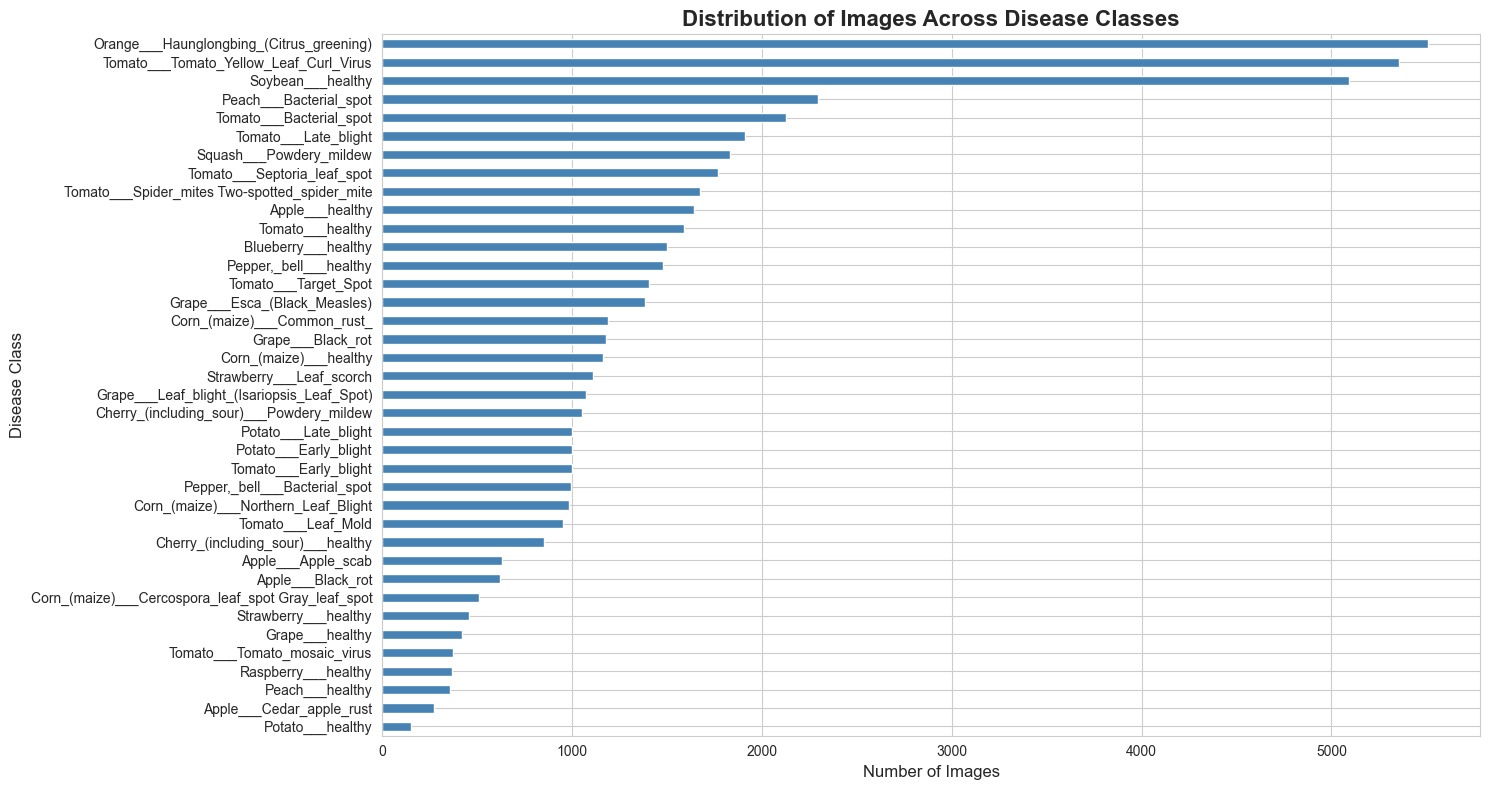


Class balance analysis:
Standard deviation: 1271.74
Coefficient of variation: 88.99%


In [10]:
# Plot class distribution
plt.figure(figsize=(15, 8))
class_dist = df['class'].value_counts().sort_values(ascending=True)
class_dist.plot(kind='barh', color='steelblue')
plt.title('Distribution of Images Across Disease Classes', fontsize=16, fontweight='bold')
plt.xlabel('Number of Images', fontsize=12)
plt.ylabel('Disease Class', fontsize=12)
plt.tight_layout()
plt.show()

print(f"\nClass balance analysis:")
print(f"Standard deviation: {class_dist.std():.2f}")
print(f"Coefficient of variation: {(class_dist.std() / class_dist.mean() * 100):.2f}%")

### <span style="color: #edf756;"> 4.2 Plant Species Distribution

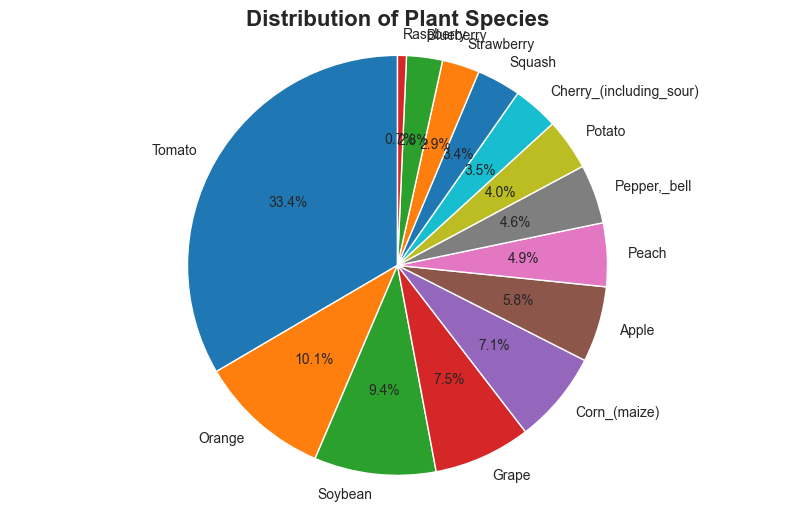


Plant species in dataset:
plant
Tomato                     18160
Orange                      5507
Soybean                     5090
Grape                       4062
Corn_(maize)                3852
Apple                       3171
Peach                       2657
Pepper,_bell                2475
Potato                      2152
Cherry_(including_sour)     1906
Squash                      1835
Strawberry                  1565
Blueberry                   1502
Raspberry                    371
Name: count, dtype: int64


In [11]:
plt.figure(figsize=(10, 6))
plant_dist = df['plant'].value_counts()
plt.pie(plant_dist.values, labels=plant_dist.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Plant Species', fontsize=16, fontweight='bold')
plt.axis('equal')
plt.show()

print(f"\nPlant species in dataset:")
print(plant_dist)

### <span style="color: #edf756;"> 4.3 Disease Distribution by Plant

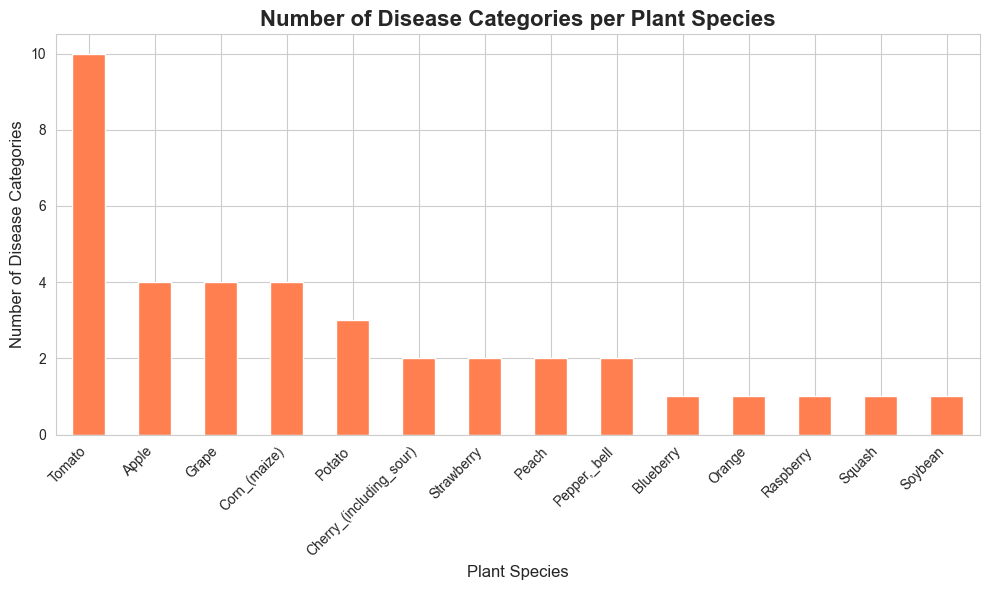


Diseases per plant:
plant
Tomato                     10
Apple                       4
Grape                       4
Corn_(maize)                4
Potato                      3
Cherry_(including_sour)     2
Strawberry                  2
Peach                       2
Pepper,_bell                2
Blueberry                   1
Orange                      1
Raspberry                   1
Squash                      1
Soybean                     1
Name: disease, dtype: int64


In [12]:
disease_per_plant = df.groupby('plant')['disease'].nunique().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
disease_per_plant.plot(kind='bar', color='coral')
plt.title('Number of Disease Categories per Plant Species', fontsize=16, fontweight='bold')
plt.xlabel('Plant Species', fontsize=12)
plt.ylabel('Number of Disease Categories', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"\nDiseases per plant:")
print(disease_per_plant)

### <span style="color: #edf756;"> 4.4 Sample Images Visualization

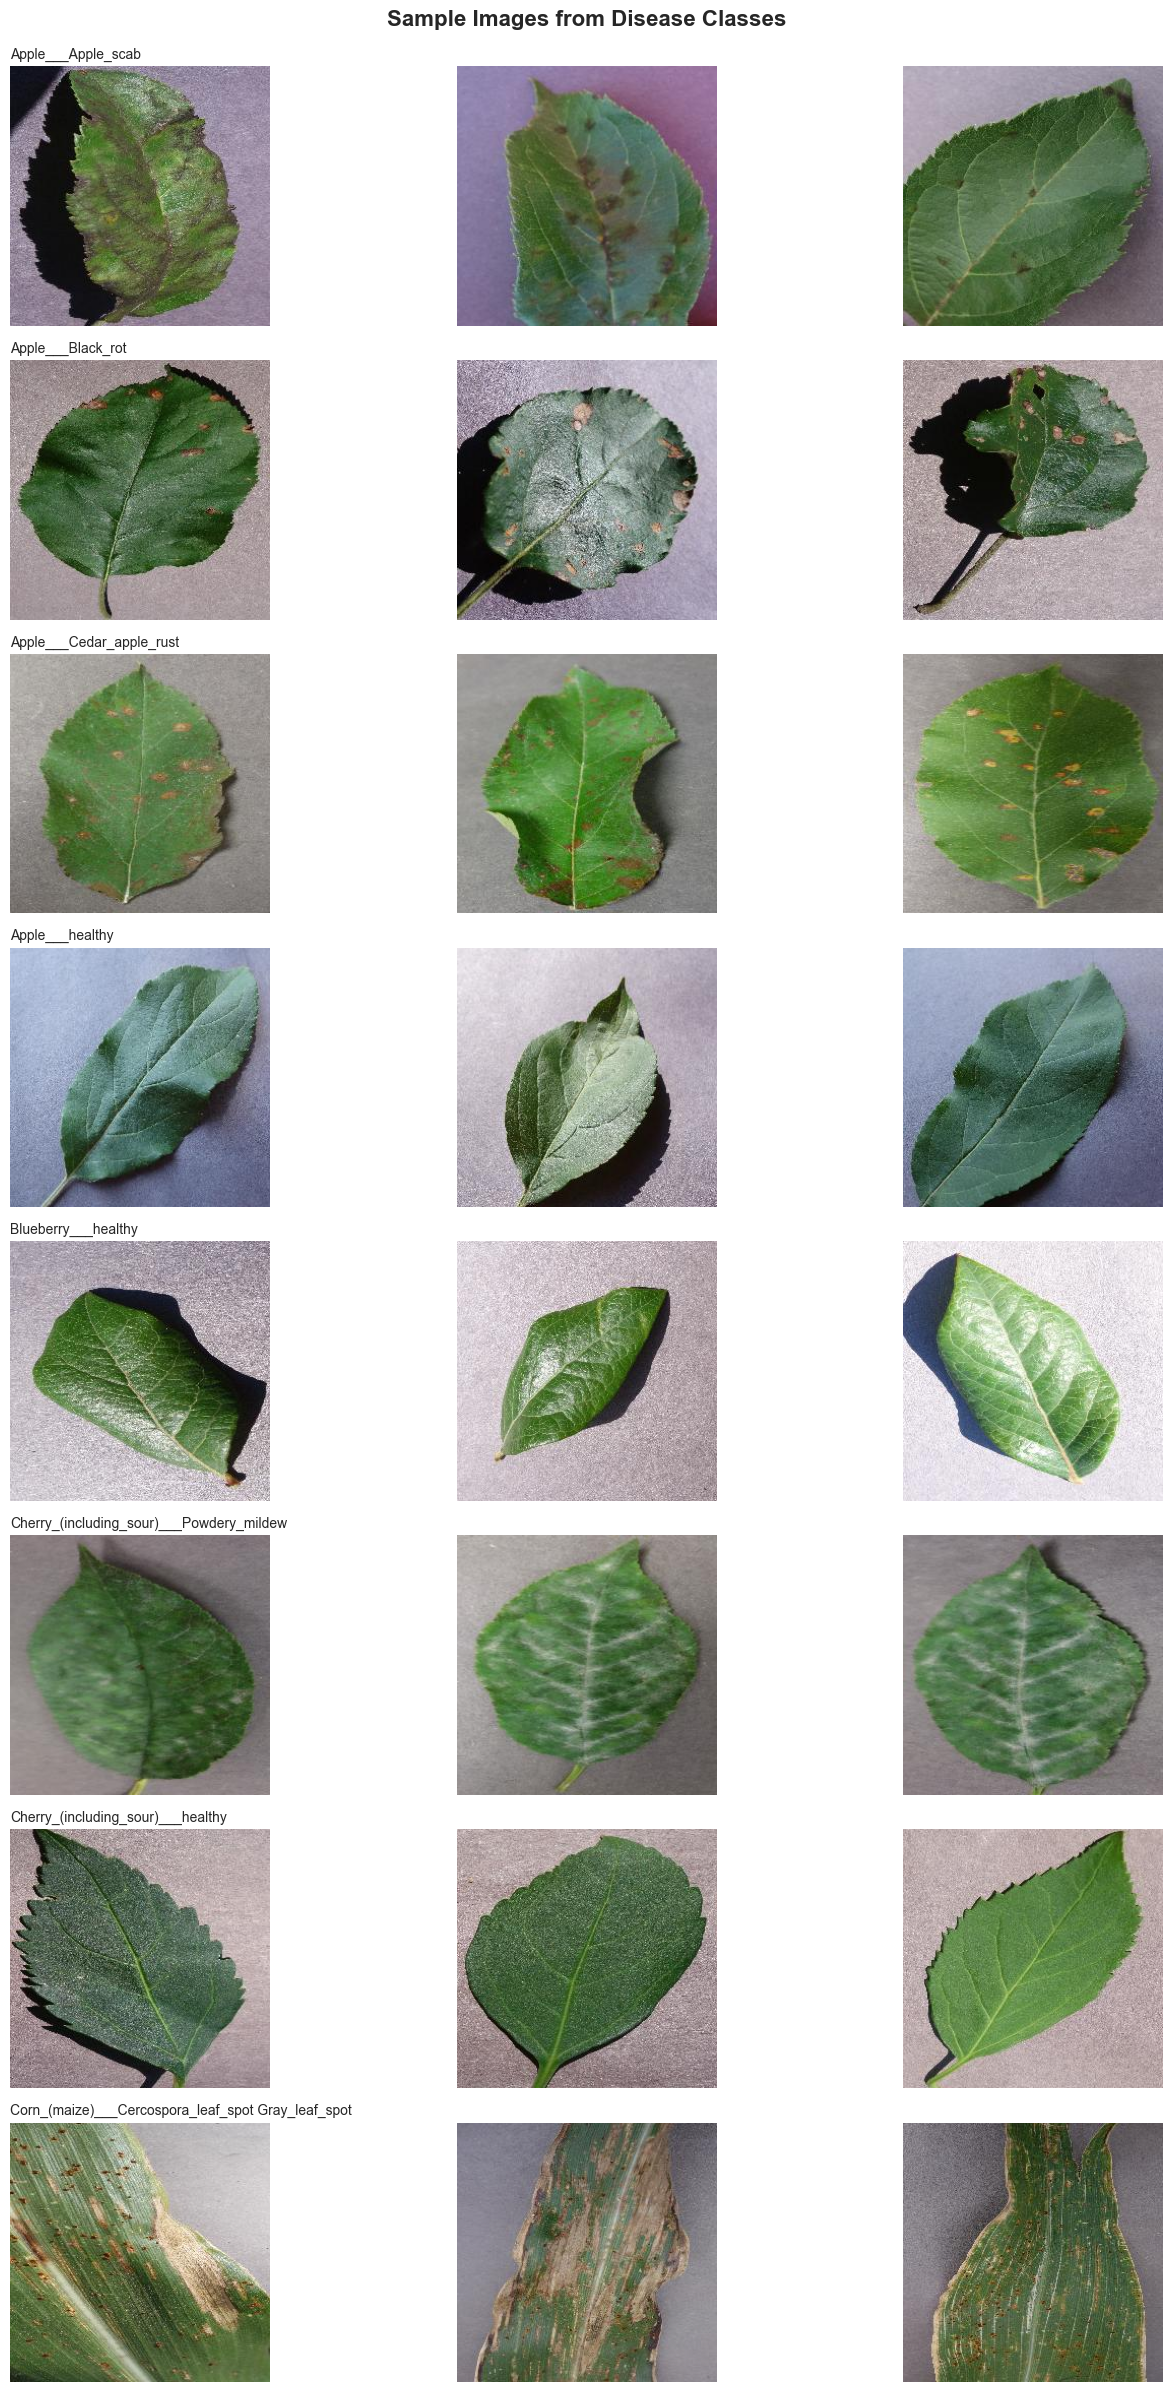

In [13]:
def display_sample_images(df, n_classes=8, images_per_class=3):
    """
    Display sample images from random classes.
    """
    sample_classes = df['class'].unique()[:n_classes]
    
    fig, axes = plt.subplots(n_classes, images_per_class, 
                            figsize=(15, n_classes * 3))
    
    for i, class_name in enumerate(sample_classes):
        class_samples = df[df['class'] == class_name].sample(
            min(images_per_class, len(df[df['class'] == class_name])),
            random_state=SEED
        )
        
        for j, (_, row) in enumerate(class_samples.iterrows()):
            img = Image.open(row['filepath'])
            axes[i, j].imshow(img)
            axes[i, j].axis('off')
            if j == 0:
                axes[i, j].set_title(f"{class_name}", 
                                    fontsize=10, loc='left')
    
    plt.suptitle('Sample Images from Disease Classes', 
                fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()

display_sample_images(df)

### <span style="color: #edf756;"> 4.5 Healthy vs Diseased Distribution

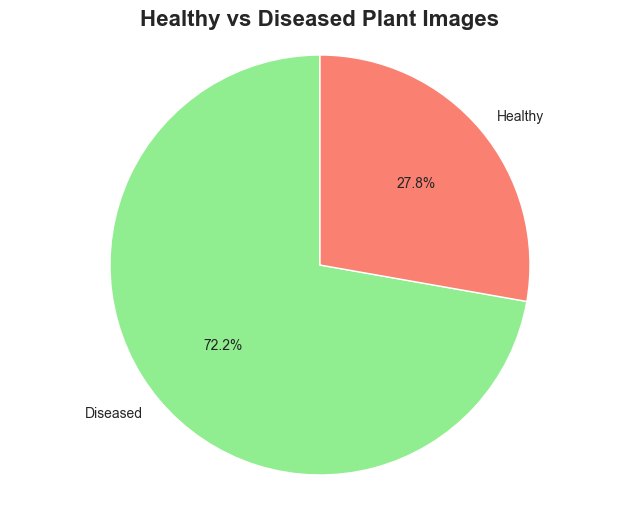


Healthy vs Diseased distribution:
status
Diseased    39221
Healthy     15084
Name: count, dtype: int64

Disease prevalence: 72.22%


In [14]:
df['status'] = df['disease'].apply(lambda x: 'Healthy' if 'healthy' in x.lower() else 'Diseased')

plt.figure(figsize=(8, 6))
status_counts = df['status'].value_counts()
plt.pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%', 
        startangle=90, colors=['lightgreen', 'salmon'])
plt.title('Healthy vs Diseased Plant Images', fontsize=16, fontweight='bold')
plt.axis('equal')
plt.show()

print(f"\nHealthy vs Diseased distribution:")
print(status_counts)
print(f"\nDisease prevalence: {(status_counts['Diseased'] / status_counts.sum() * 100):.2f}%")

### <span style="color: #edf756;"> 4.6 Image Dimension Analysis

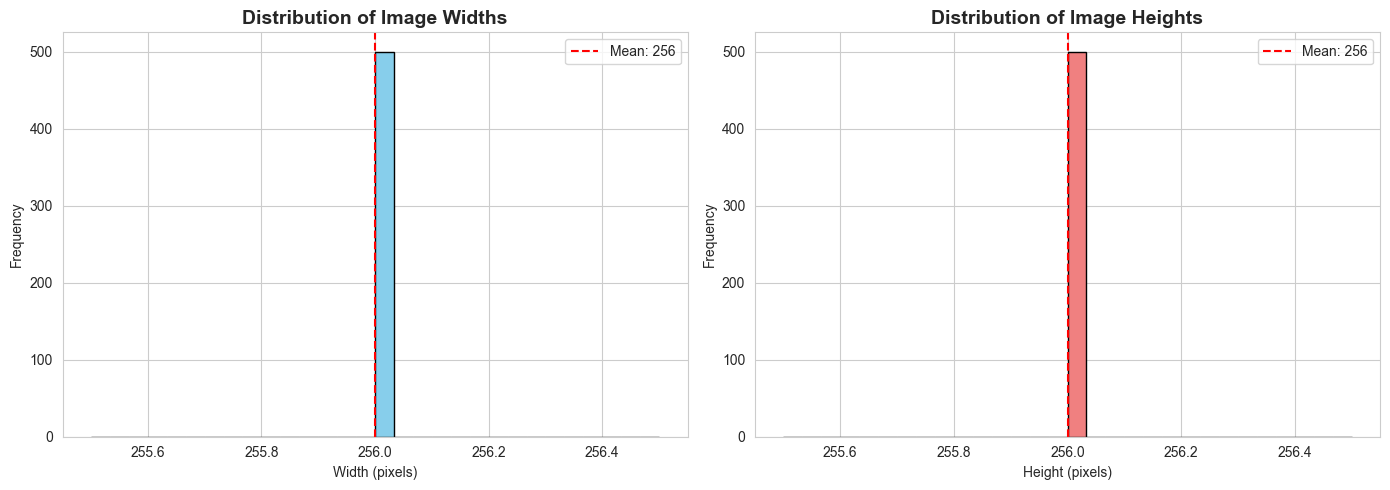

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Width distribution
axes[0].hist(img_props_df['width'], bins=30, color='skyblue', edgecolor='black')
axes[0].set_title('Distribution of Image Widths', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Width (pixels)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(img_props_df['width'].mean(), color='red', 
                linestyle='--', label=f"Mean: {img_props_df['width'].mean():.0f}")
axes[0].legend()

# Height distribution
axes[1].hist(img_props_df['height'], bins=30, color='lightcoral', edgecolor='black')
axes[1].set_title('Distribution of Image Heights', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Height (pixels)')
axes[1].set_ylabel('Frequency')
axes[1].axvline(img_props_df['height'].mean(), color='red', 
                linestyle='--', label=f"Mean: {img_props_df['height'].mean():.0f}")
axes[1].legend()

plt.tight_layout()
plt.show()

## <span style="color: #9df9ef;"> 5. Data Preprocessing <a name="preprocessing"></a>
Preparing data for model training.

### <span style="color: #edf756;"> 5.1 Define image parameters

In [16]:
IMG_SIZE = 224  # MobileNetV2 expects 224x224
BATCH_SIZE = 32
EPOCHS = 10

# Split data into train, validation, and test sets
train_df, temp_df = train_test_split(df, test_size=0.3, 
                                     stratify=df['class'], 
                                     random_state=SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.5, 
                                   stratify=temp_df['class'], 
                                   random_state=SEED)

print(f"Training set: {len(train_df)} images ({len(train_df)/len(df)*100:.1f}%)")
print(f"Validation set: {len(val_df)} images ({len(val_df)/len(df)*100:.1f}%)")
print(f"Test set: {len(test_df)} images ({len(test_df)/len(df)*100:.1f}%)")

Training set: 38013 images (70.0%)
Validation set: 8146 images (15.0%)
Test set: 8146 images (15.0%)


### <span style="color: #edf756;"> 5.2 Create ImageDataGenerator with augmentation for training

In [17]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Validation and test generators (only rescaling)
val_test_datagen = ImageDataGenerator(rescale=1./255)

print("Data augmentation configured for training set.")
print("Validation and test sets will use only rescaling.")

Data augmentation configured for training set.
Validation and test sets will use only rescaling.


### <span style="color: #edf756;"> 5.3 Create Data generators

In [18]:
train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col='filepath',
    y_col='class',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)

val_generator = val_test_datagen.flow_from_dataframe(
    val_df,
    x_col='filepath',
    y_col='class',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_dataframe(
    test_df,
    x_col='filepath',
    y_col='class',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"\nData generators created successfully!")
print(f"Number of classes: {len(train_generator.class_indices)}")

Found 38013 validated image filenames belonging to 38 classes.
Found 8146 validated image filenames belonging to 38 classes.
Found 8146 validated image filenames belonging to 38 classes.

Data generators created successfully!
Number of classes: 38


## <span style="color: #9df9ef;"> 6. Baseline Model Development <a name="baseline"></a>
Building a baseline CNN model using transfer learning with MobileNetV2.

### <span style="color: #edf756;"> 6.1 Load pre-trained MobileNetV2 (without top layers)

In [19]:
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze base model layers
base_model.trainable = False

print(f"Base model loaded: MobileNetV2")
print(f"Number of layers: {len(base_model.layers)}")
print(f"Trainable: {base_model.trainable}")

Base model loaded: MobileNetV2
Number of layers: 154
Trainable: False


### <span style="color: #edf756;"> 6.2  Build the model

In [20]:
inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(len(train_generator.class_indices), activation='softmax')(x)

model = Model(inputs, outputs)

# Compile the model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\nModel compiled successfully!")
model.summary()


Model compiled successfully!


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 38)             │        48,678 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,306,662 (8.80 MB)

 Trainable params: 48,678 (190.15 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### <span style="color: #edf756;"> 6.3 Define callbacks

In [ ]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

checkpoint = keras.callbacks.ModelCheckpoint(
    "../models/best_model_Baseline.keras",
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

print("Callbacks configured:")
print("- Early stopping (patience=3)")
print("- Learning rate reduction (patience=2)")

Callbacks configured:
- Early stopping (patience=3)
- Learning rate reduction (patience=2)


### <span style="color: #edf756;"> 6.4 Train the model

In [22]:
print(f"\nStarting training for {EPOCHS} epochs...")

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[early_stopping, reduce_lr, checkpoint],
    verbose=1
)

print("\nTraining complete!")


Starting training for 10 epochs...
Epoch 1/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7030 - loss: 1.1344
Epoch 1: val_loss improved from None to 0.31968, saving model to best_model_Baseline.h5


1188/1188 ━━━━━━━━━━━━━━━━━━━━ 1686s 1s/step - accuracy: 0.8154 - loss: 0.6595 - val_accuracy: 0.9027 - val_loss: 0.3197 - learning_rate: 0.0010
Epoch 2/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8928 - loss: 0.3381
Epoch 2: val_loss improved from 0.31968 to 0.24459, saving model to best_model_Baseline.h5


1188/1188 ━━━━━━━━━━━━━━━━━━━━ 1592s 1s/step - accuracy: 0.8977 - loss: 0.3248 - val_accuracy: 0.9233 - val_loss: 0.2446 - learning_rate: 0.0010
Epoch 3/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9100 - loss: 0.2824
Epoch 3: val_loss improved from 0.24459 to 0.23033, saving model to best_model_Baseline.h5


1188/1188 ━━━━━━━━━━━━━━━━━━━━ 1420s 1s/step - accuracy: 0.9106 - loss: 0.2785 - val_accuracy: 0.9220 - val_loss: 0.2303 - learning_rate: 0.0010
Epoch 4/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 0s 952ms/step - accuracy: 0.9135 - loss: 0.2631
Epoch 4: val_loss improved from 0.23033 to 0.20994, saving model to best_model_Baseline.h5


1188/1188 ━━━━━━━━━━━━━━━━━━━━ 1307s 1s/step - accuracy: 0.9152 - loss: 0.2581 - val_accuracy: 0.9315 - val_loss: 0.2099 - learning_rate: 0.0010
Epoch 5/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 0s 801ms/step - accuracy: 0.9209 - loss: 0.2399
Epoch 5: val_loss improved from 0.20994 to 0.20776, saving model to best_model_Baseline.h5


1188/1188 ━━━━━━━━━━━━━━━━━━━━ 1055s 888ms/step - accuracy: 0.9185 - loss: 0.2460 - val_accuracy: 0.9313 - val_loss: 0.2078 - learning_rate: 0.0010
Epoch 6/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 0s 747ms/step - accuracy: 0.9215 - loss: 0.2288
Epoch 6: val_loss improved from 0.20776 to 0.19399, saving model to best_model_Baseline.h5


1188/1188 ━━━━━━━━━━━━━━━━━━━━ 987s 831ms/step - accuracy: 0.9234 - loss: 0.2302 - val_accuracy: 0.9394 - val_loss: 0.1940 - learning_rate: 0.0010
Epoch 7/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 0s 712ms/step - accuracy: 0.9260 - loss: 0.2266
Epoch 7: val_loss did not improve from 0.19399
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 949s 799ms/step - accuracy: 0.9233 - loss: 0.2333 - val_accuracy: 0.9260 - val_loss: 0.2347 - learning_rate: 0.0010
Epoch 8/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 0s 724ms/step - accuracy: 0.9256 - loss: 0.2232
Epoch 8: val_loss improved from 0.19399 to 0.17971, saving model to best_model_Baseline.h5


1188/1188 ━━━━━━━━━━━━━━━━━━━━ 962s 809ms/step - accuracy: 0.9240 - loss: 0.2263 - val_accuracy: 0.9408 - val_loss: 0.1797 - learning_rate: 0.0010
Epoch 9/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 0s 963ms/step - accuracy: 0.9273 - loss: 0.2161
Epoch 9: val_loss did not improve from 0.17971
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 1250s 1s/step - accuracy: 0.9264 - loss: 0.2227 - val_accuracy: 0.9340 - val_loss: 0.2018 - learning_rate: 0.0010
Epoch 10/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 0s 721ms/step - accuracy: 0.9296 - loss: 0.2113
Epoch 10: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.

Epoch 10: val_loss did not improve from 0.17971
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 961s 808ms/step - accuracy: 0.9269 - loss: 0.2185 - val_accuracy: 0.9395 - val_loss: 0.1818 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 8.

Training complete!


##### <span style="color: #a28089;"> Notes: </span>
- <span style="color: #f19e9e;"> This notebook was originally trained and saved using the `.h5` (HDF5) format. The checkpoint path has since been updated to use the native Keras format (`.keras`) as recommended by TensorFlow/Keras. The training outputs above reflect the original training run and may show legacy format warnings — these do not affect model performance, accuracy results, or any findings reported in this notebook.

### <span style="color: #edf756;"> 6.5 Visualize Training History

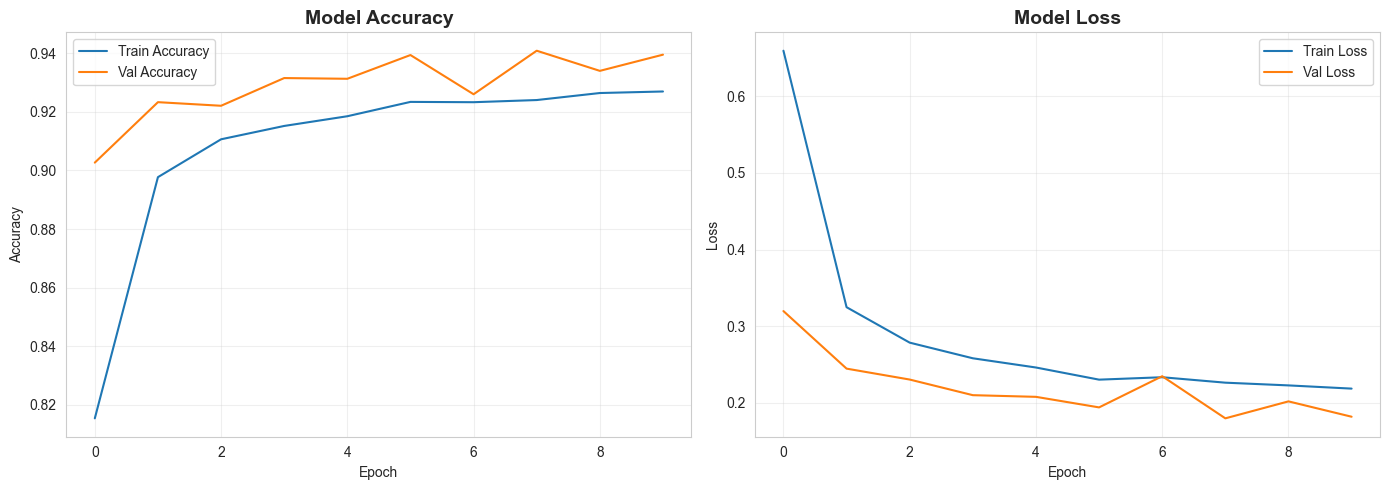


Final Training Accuracy: 0.9269
Final Validation Accuracy: 0.9395


In [23]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print final metrics
print(f"\nFinal Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")

## <span style="color: #9df9ef;"> 7. Model Evaluation <a name="evaluation"></a>
Evaluating the baseline model on the test set.

### <span style="color: #edf756;"> 7.1 Test Set Evaluation

In [24]:
# Evaluate on test set
print("Evaluating model on test set...\n")
test_loss, test_accuracy = model.evaluate(test_generator)

print(f"\n{'='*50}")
print(f"TEST SET RESULTS")
print(f"{'='*50}")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"{'='*50}")

Evaluating model on test set...

255/255 ━━━━━━━━━━━━━━━━━━━━ 125s 488ms/step - accuracy: 0.9446 - loss: 0.1784

TEST SET RESULTS
Test Loss: 0.1784
Test Accuracy: 0.9446 (94.46%)


In [25]:
# Get predictions
print("Generating predictions on test set...")
test_generator.reset()
y_pred_probs = model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes

print(f"Predictions generated for {len(y_pred)} samples.")

Generating predictions on test set...
255/255 ━━━━━━━━━━━━━━━━━━━━ 78s 303ms/step
Predictions generated for 8146 samples.


### <span style="color: #edf756;"> 7.2 Confusion Matrix

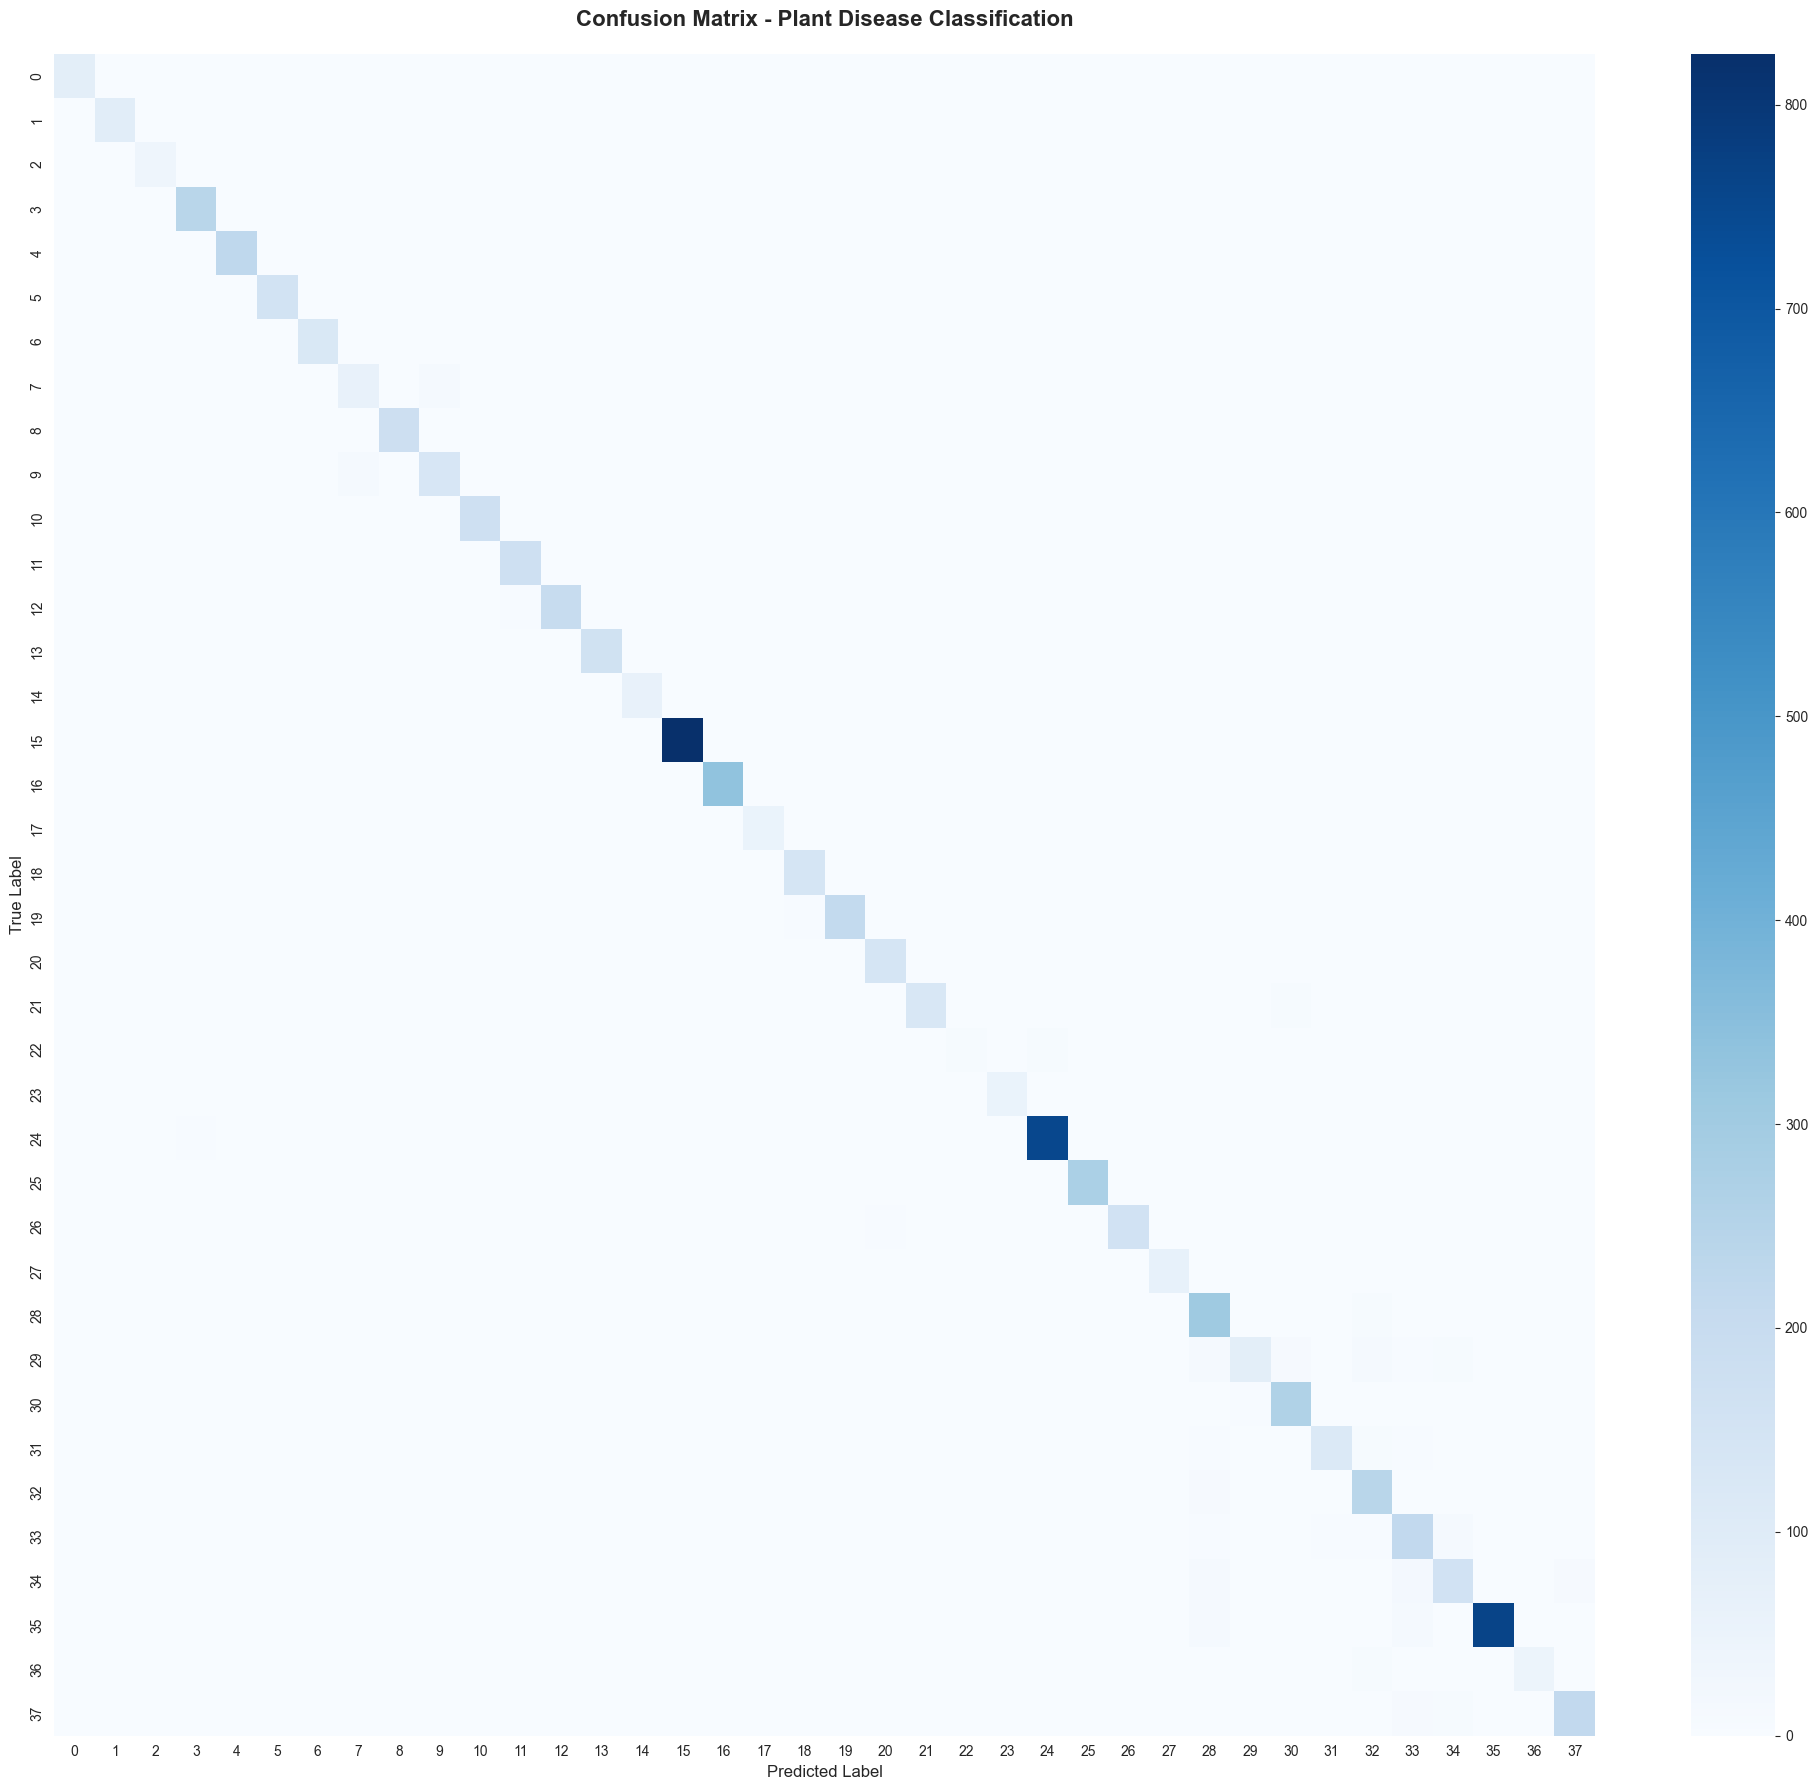

Confusion matrix generated (values not shown due to 38 classes).


In [26]:
# Generate confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix (simplified for 38 classes)
plt.figure(figsize=(20, 18))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', cbar=True)
plt.title('Confusion Matrix - Plant Disease Classification', 
         fontsize=16, fontweight='bold', pad=20)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

print("Confusion matrix generated (values not shown due to 38 classes).")

In [28]:
# Analyze confusion patterns
print("\n" + "="*60)
print("MISCLASSIFICATION PATTERN ANALYSIS")
print("="*60)

# Get confusion matrix
cm = confusion_matrix(y_true, y_pred)
class_labels = list(train_generator.class_indices.keys())

# Find most common confusions (excluding diagonal)
confusions = []
for i in range(len(cm)):
    for j in range(len(cm)):
        if i != j and cm[i][j] > 5:  # More than 5 confusions
            confusions.append({
                'true': class_labels[i],
                'predicted': class_labels[j],
                'count': cm[i][j],
                'true_total': cm[i].sum()
            })

# Sort by confusion count
confusions_sorted = sorted(confusions, key=lambda x: x['count'], reverse=True)

print("\nTop 10 Most Common Misclassifications:")
print("-" * 60)
for idx, conf in enumerate(confusions_sorted[:10], 1):
    pct = (conf['count'] / conf['true_total']) * 100
    print(f"{idx}. TRUE: {conf['true'][:40]}")
    print(f"   PREDICTED: {conf['predicted'][:40]}")
    print(f"   Count: {conf['count']} ({pct:.1f}% of true class)")
    print()

# Pattern analysis
print("\nCommon Confusion Patterns:")
print("-" * 60)

# 1. Same plant, different disease
same_plant_confusions = [c for c in confusions_sorted 
                        if c['true'].split('___')[0] == c['predicted'].split('___')[0]]
if same_plant_confusions:
    print(f"\n1. SAME PLANT, DIFFERENT DISEASE ({len(same_plant_confusions)} cases)")
    for conf in same_plant_confusions[:3]:
        print(f"   - {conf['true'].split('___')[1]} ↔ {conf['predicted'].split('___')[1]}")
        print(f"     (both on {conf['true'].split('___')[0]})")

# 2. Healthy vs diseased confusion
healthy_confusions = [c for c in confusions_sorted 
                     if 'healthy' in c['true'].lower() or 'healthy' in c['predicted'].lower()]
if healthy_confusions:
    print(f"\n2. HEALTHY vs DISEASED CONFUSION ({len(healthy_confusions)} cases)")
    for conf in healthy_confusions[:3]:
        true_status = "HEALTHY" if 'healthy' in conf['true'].lower() else "DISEASED"
        pred_status = "HEALTHY" if 'healthy' in conf['predicted'].lower() else "DISEASED"
        print(f"   - {true_status} → {pred_status}: {conf['count']} errors")

# 3. Similar disease types across plants
disease_types = {}
for conf in confusions_sorted[:20]:
    true_disease = conf['true'].split('___')[1].lower()
    pred_disease = conf['predicted'].split('___')[1].lower()
    
    # Check for similar disease names
    for keyword in ['spot', 'blight', 'rust', 'rot', 'mildew']:
        if keyword in true_disease and keyword in pred_disease:
            if keyword not in disease_types:
                disease_types[keyword] = []
            disease_types[keyword].append(conf)

if disease_types:
    print(f"\n3. SIMILAR DISEASE TYPES")
    for disease_type, confs in disease_types.items():
        if confs:
            print(f"   - {disease_type.upper()} diseases confused: {len(confs)} cases")

print("\n" + "="*60)


MISCLASSIFICATION PATTERN ANALYSIS

Top 10 Most Common Misclassifications:
------------------------------------------------------------
1. TRUE: Tomato___Target_Spot
   PREDICTED: Tomato___Spider_mites Two-spotted_spider
   Count: 18 (8.5% of true class)

2. TRUE: Tomato___Target_Spot
   PREDICTED: Tomato___Bacterial_spot
   Count: 16 (7.6% of true class)

3. TRUE: Tomato___Tomato_Yellow_Leaf_Curl_Virus
   PREDICTED: Tomato___Bacterial_spot
   Count: 16 (2.0% of true class)

4. TRUE: Corn_(maize)___Cercospora_leaf_spot Gray
   PREDICTED: Corn_(maize)___Northern_Leaf_Blight
   Count: 14 (18.2% of true class)

5. TRUE: Tomato___Early_blight
   PREDICTED: Tomato___Septoria_leaf_spot
   Count: 14 (9.3% of true class)

6. TRUE: Tomato___Spider_mites Two-spotted_spider
   PREDICTED: Tomato___Target_Spot
   Count: 14 (5.6% of true class)

7. TRUE: Tomato___Tomato_Yellow_Leaf_Curl_Virus
   PREDICTED: Tomato___Spider_mites Two-spotted_spider
   Count: 14 (1.7% of true class)

8. TRUE: Corn_(ma

### <span style="color: #edf756;"> 7.3 Classification Report

In [29]:
# Generate classification report
class_labels = list(train_generator.class_indices.keys())
report = classification_report(y_true, y_pred, target_names=class_labels, 
                              output_dict=True, zero_division=0)

# Convert to DataFrame for better visualization
report_df = pd.DataFrame(report).transpose()

print("\nClassification Report:")
print(report_df)  
#print("\n... (showing first 10 classes only) ...\n")

# Show summary statistics
print("\nSummary Statistics:")
print(report_df.loc[['accuracy', 'macro avg', 'weighted avg']])


Classification Report:
                                                    precision    recall  \
Apple___Apple_scab                                   0.934783  0.914894   
Apple___Black_rot                                    0.978495  0.978495   
Apple___Cedar_apple_rust                             0.975610  0.975610   
Apple___healthy                                      0.956349  0.979675   
Blueberry___healthy                                  1.000000  0.991150   
Cherry_(including_sour)___Powdery_mildew             1.000000  0.993671   
Cherry_(including_sour)___healthy                    0.976562  0.976562   
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot   0.787500  0.818182   
Corn_(maize)___Common_rust_                          0.994413  0.994413   
Corn_(maize)___Northern_Leaf_Blight                  0.899329  0.911565   
Corn_(maize)___healthy                               1.000000  0.988506   
Grape___Black_rot                                    0.956044  0.983051   
G

### <span style="color: #edf756;"> 7.4 Per-Class Performance Analysis

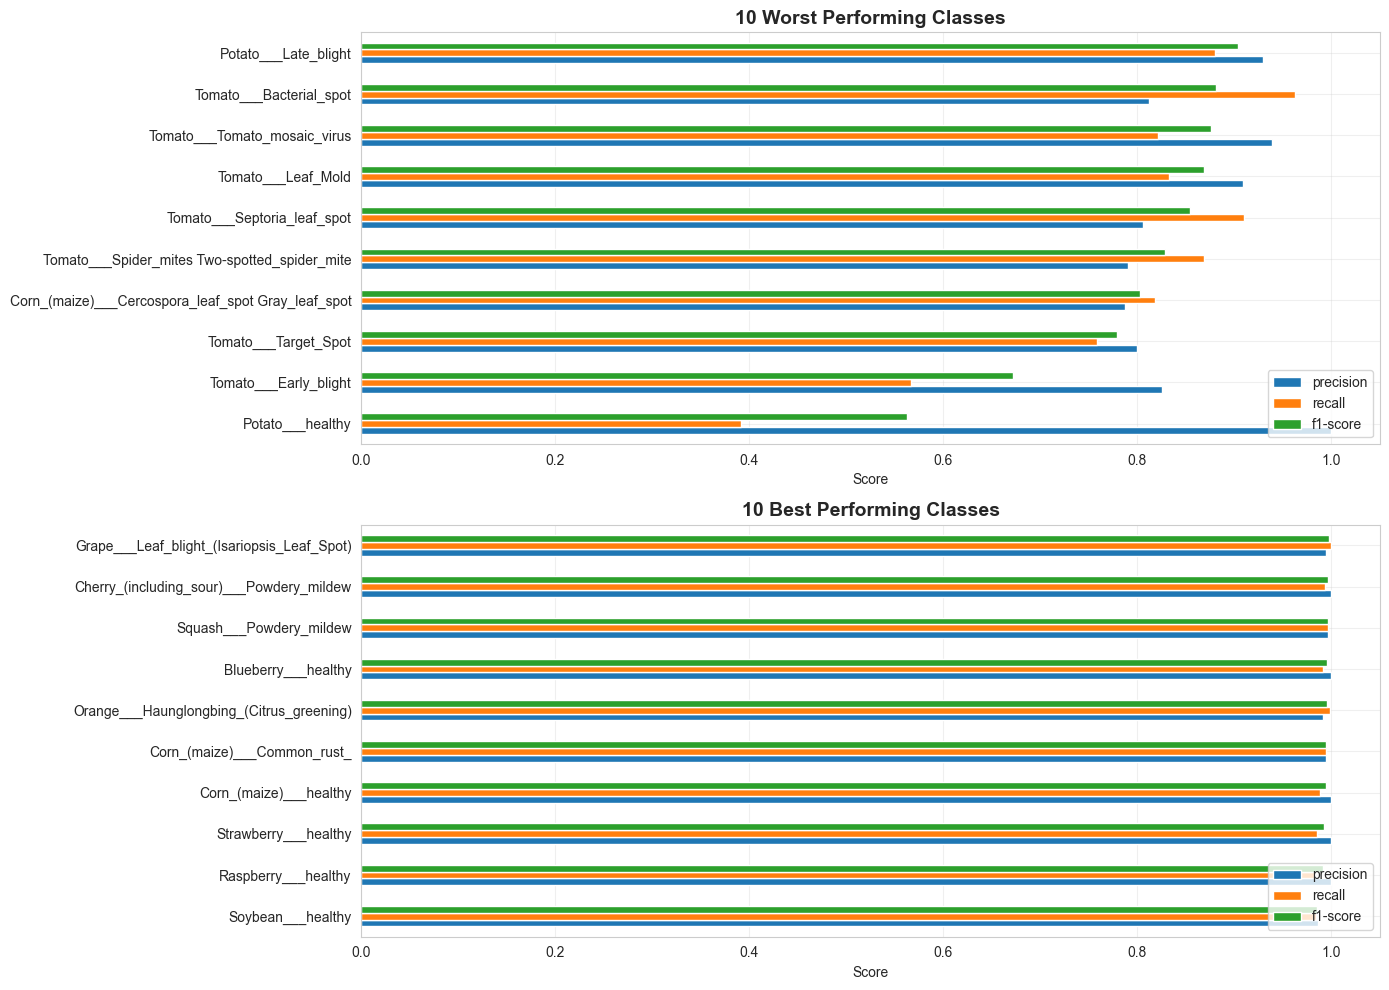

In [30]:
# Analyze per-class performance
class_performance = report_df.iloc[:-3][['precision', 'recall', 'f1-score']].sort_values(
    by='f1-score', ascending=True
)

# Plot top 10 best and worst performing classes
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Worst performing
worst_10 = class_performance.head(10)
worst_10[['precision', 'recall', 'f1-score']].plot(kind='barh', ax=axes[0])
axes[0].set_title('10 Worst Performing Classes', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Score')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# Best performing
best_10 = class_performance.tail(10)
best_10[['precision', 'recall', 'f1-score']].plot(kind='barh', ax=axes[1])
axes[1].set_title('10 Best Performing Classes', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Score')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### <span style="color: #edf756;"> 7.5 Sample Predictions Visualization

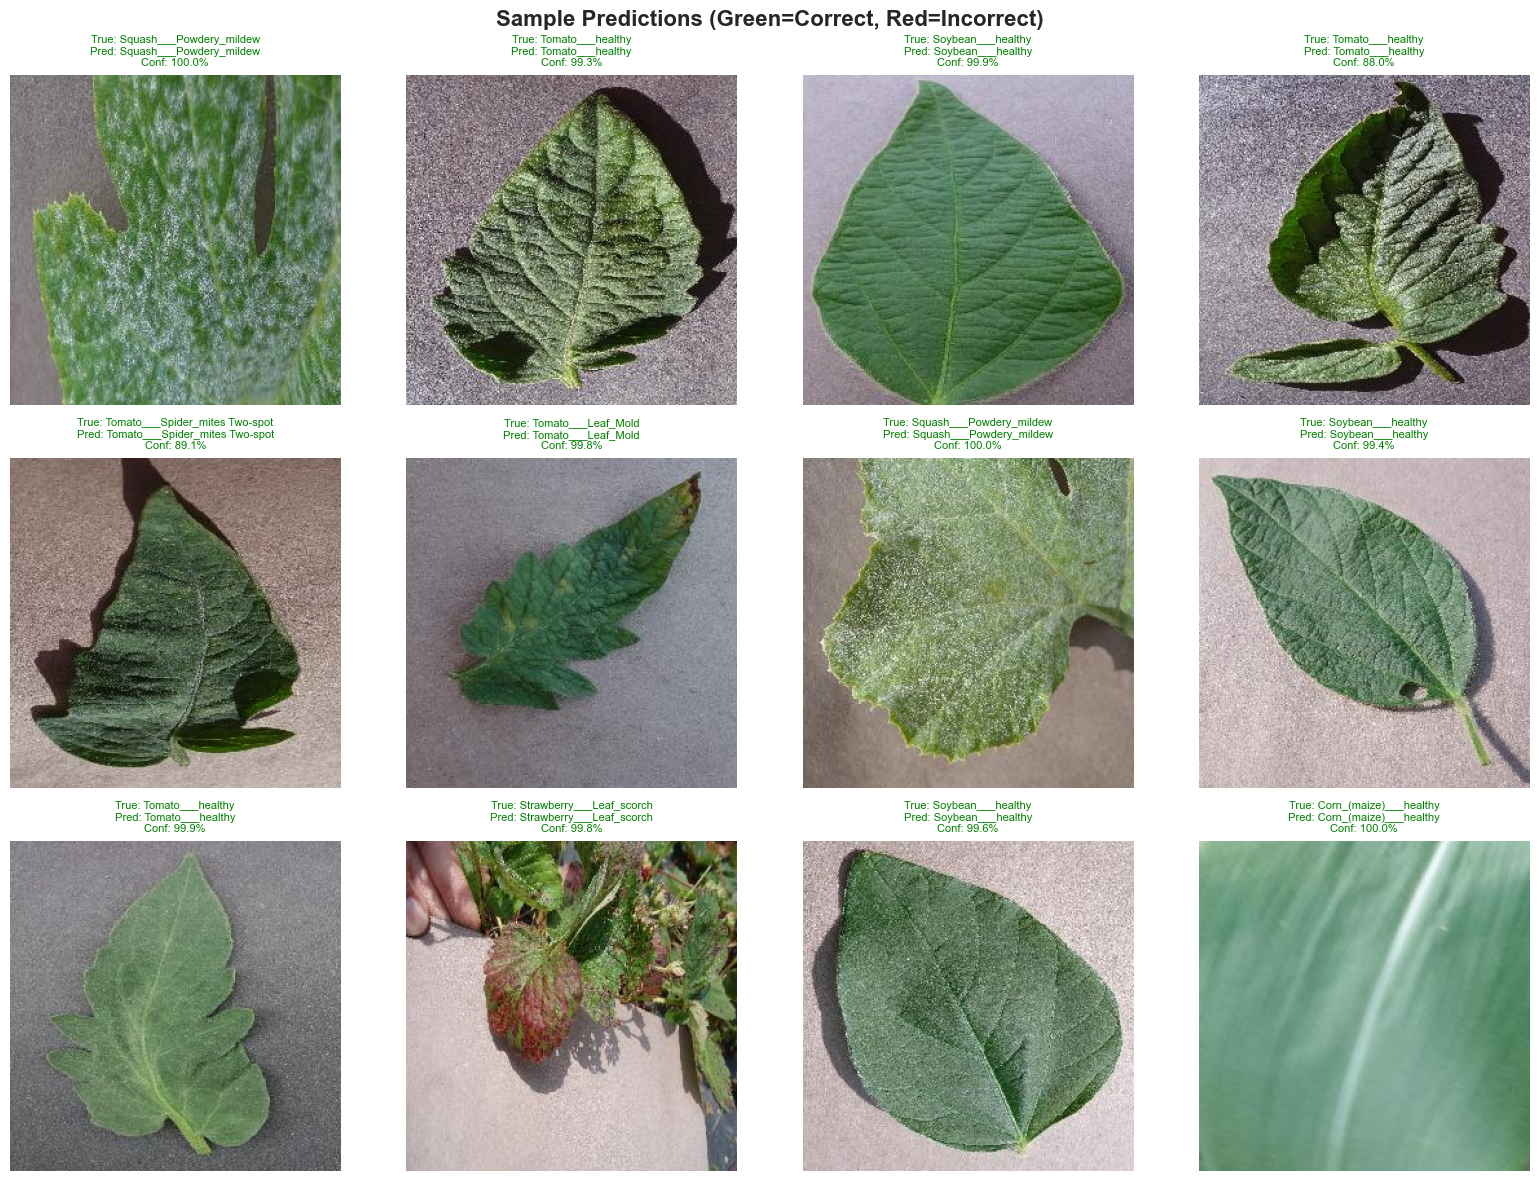

In [31]:
# Visualize some predictions
def visualize_predictions(generator, predictions, n_samples=12):
    """
    Visualize random sample predictions.
    """
    # Get random indices
    indices = np.random.choice(len(predictions), n_samples, replace=False)
    
    # Get class names
    class_names = list(generator.class_indices.keys())
    
    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    axes = axes.ravel()
    
    for i, idx in enumerate(indices):
        # Get image path
        img_path = generator.filepaths[idx]
        img = Image.open(img_path)
        
        # Get true and predicted labels
        true_label = class_names[generator.classes[idx]]
        pred_label = class_names[predictions[idx]]
        confidence = y_pred_probs[idx][predictions[idx]] * 100
        
        # Determine if prediction is correct
        is_correct = true_label == pred_label
        color = 'green' if is_correct else 'red'
        
        # Plot
        axes[i].imshow(img)
        axes[i].axis('off')
        title = f"True: {true_label[:30]}\nPred: {pred_label[:30]}\nConf: {confidence:.1f}%"
        axes[i].set_title(title, fontsize=8, color=color)
    
    plt.suptitle('Sample Predictions (Green=Correct, Red=Incorrect)', 
                fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

visualize_predictions(test_generator, y_pred)

### <span style="color: #edf756;"> 7.6 Model Performance Metrics Summary

In [32]:
# Create summary metrics
metrics_summary = {
    'Metric': ['Test Accuracy', 'Macro Avg Precision', 'Macro Avg Recall', 
              'Macro Avg F1-Score', 'Weighted Avg Precision', 'Weighted Avg Recall',
              'Weighted Avg F1-Score'],
    'Score': [
        test_accuracy,
        report['macro avg']['precision'],
        report['macro avg']['recall'],
        report['macro avg']['f1-score'],
        report['weighted avg']['precision'],
        report['weighted avg']['recall'],
        report['weighted avg']['f1-score']
    ]
}

metrics_df = pd.DataFrame(metrics_summary)
metrics_df['Score'] = metrics_df['Score'].apply(lambda x: f"{x:.4f}")

print("\n" + "="*60)
print("MODEL PERFORMANCE SUMMARY")
print("="*60)
print(metrics_df.to_string(index=False))
print("="*60)


MODEL PERFORMANCE SUMMARY
                Metric  Score
         Test Accuracy 0.9446
   Macro Avg Precision 0.9407
      Macro Avg Recall 0.9205
    Macro Avg F1-Score 0.9258
Weighted Avg Precision 0.9464
   Weighted Avg Recall 0.9446
 Weighted Avg F1-Score 0.9440


## <span style="color: #9df9ef;"> 8. Summary and Next Steps <a name="summary"></a>

### <span style="color: #edf756;"> 8.1 Key Findings from EDA:

1. **Dataset Characteristics:**
   - Total images: **54,305**
   - Number of classes: **38**
   - Class distribution: **Significantly Imbalanced (CV=88.99%, 36.23x range)**
   - Image dimensions: **Mostly uniform at [256x256]**

2. **Data Quality:**
   - No missing values detected
   - No duplicate images found
   - Minimal to no corrupted images in sample check
   - Images are in **RGB/JPEG** format

3. **Disease Distribution:**
   - Healthy vs Diseased ratio: **Disease prevalence: 72.22%**
   - Most represented plant: **Tomato with count of 18160 (33.4%)**
   - Plant with most disease categories: **Tomato (10 diseases)**

### <span style="color: #edf756;"> 8.2 Baseline Model Performance:

- **Architecture:** Transfer Learning with MobileNetV2
- **Test Accuracy:** 94.46%
- **Test Loss:** 0.1784
- **Training Time:** ~4-5 hours on Google Colab T4 GPU
- **Final Training Accuracy:** 92.69%
- **Final Validation Accuracy:** 93.95%

**Performance Metrics:**

| Metric | Score |
|--------|-------|
| Test Accuracy | 94.46% |
| Macro Avg Precision | 0.9407 |
| Macro Avg Recall | 0.9205 |
| Macro Avg F1-Score | 0.9258 |
| Weighted Avg Precision | 0.9464 |
| Weighted Avg Recall | 0.9446 |
| Weighted Avg F1-Score | 0.9440 |

**Key Observations:**

**Strengths:**
- Strong overall performance (94.46%) demonstrating effective transfer learning
- Minimal overfitting: Training (92.69%), Validation (93.95%), Test (94.46%)
- Excellent plant species identification (zero cross-species errors in top 10)
- Near-perfect performance on distinctive diseases (F1 > 0.99 for powdery mildew, leaf blight)
- Bidirectional confusion patterns indicate genuine uncertainty rather than systematic bias

**Best Performing Classes (F1-Score > 0.99):**
1. Grape___Leaf_blight (F1: 0.9969) - Distinctive lesion patterns
2. Cherry___Powdery_mildew (F1: 0.9968) - Clear white coating symptoms
3. Squash___Powdery_mildew (F1: 0.9964) - Similar distinctive white symptoms
4. Blueberry___healthy (F1: 0.9956) - Clear healthy leaf appearance
5. Orange___Haunglongbing (F1: 0.9952) - Characteristic chlorosis pattern

**Worst Performing Classes (F1-Score < 0.85):**
1. Potato___healthy (F1: 0.5625) - Severely under-represented (only 152 training images)
2. Tomato___Early_blight (F1: 0.6719) - Subtle early-stage symptoms, confused with other tomato diseases
3. Tomato___Target_Spot (F1: 0.7786) - Similar appearance to spider mites and bacterial spot
4. Corn___Gray_leaf_spot (F1: 0.8025) - Frequently confused with Northern Leaf Blight (18.2% error rate)
5. Tomato___Spider_mites (F1: 0.8280) - Subtle pest damage with small visual cues

**Weaknesses:**

1. **Tomato disease differentiation (80% of top errors):**
   - Target Spot ↔ Spider mites: 32 combined errors (most confused pair)
   - Bacterial spot over-predicted: 57 false positives from 4 different diseases
   - Root cause: Over-representation in training data (33% of dataset) + similar spot-like symptoms

2. **Corn leaf disease confusion (27 combined errors):**
   - Gray leaf spot ↔ Northern Leaf Blight confused bidirectionally
   - 18.2% error rate on Gray leaf spot (highest single-class confusion)
   - Known challenge even for human experts - both cause elongated lesions

3. **Class imbalance impact:**
   - Potato healthy: Only 152 training images → F1: 0.563
   - Raspberry: Only 371 images total → Limited model exposure
   - Under-represented classes consistently perform worse

4. **Subtle symptom detection:**
   - Early-stage diseases (Early blight F1: 0.672)
   - Pest damage (Spider mites F1: 0.828)
   - Bacterial spots on multiple tomato diseases confused

**Error Pattern Analysis:**

1. **Same-plant errors (65% of top confusions):**
   - Model learns plant species very well (no cross-plant errors in top 10)
   - Main weakness: Disease differentiation within same plant
   - Tomato diseases account for 8 of top 10 error cases

2. **Bacterial spot as confusion hub (57 false positives):**
   - Incorrectly predicted for: Target Spot (16), Yellow Leaf Curl Virus (16), Septoria leaf spot (12), Early blight (13)
   - Model appears to use bacterial spot as "default" for ambiguous tomato leaf damage
   - Suggests need for finer-grained feature learning for spot size, distribution, and texture

3. **Bidirectional confusion patterns (genuine model uncertainty):**
   - Target Spot ↔ Spider mites: 32 total errors (18 forward + 14 backward)
   - Corn diseases ↔ each other: 27 total errors (14 forward + 13 backward)
   - **This is actually positive:** Shows model isn't systematically biased, just genuinely unsure
   - Candidates for ensemble methods or confidence thresholding in Module 24

4. **Disease type clustering:**
   - Spot diseases confused with each other: Target Spot, Bacterial spot, Septoria leaf spot, Gray leaf spot
   - Blight diseases confused with each other: Early blight, Northern Leaf Blight
   - Model struggles with diseases sharing symptom terminology and appearance

5. **Botanically reasonable confusions:**
   - All major confusions involve visually similar diseases
   - Corn Gray leaf spot ↔ Northern Leaf Blight: Even agricultural experts find these challenging
   - Target Spot ↔ Spider mites: Both cause discoloration/damage on tomato leaves

**Overall Assessment:**

The baseline MobileNetV2 model demonstrates **strong performance** (94.46% test accuracy) and establishes a solid foundation for further improvements in Module 24. The model excels at plant species identification and distinctive disease detection, but struggles with subtle symptoms, early-stage diseases, and differentiation among visually similar diseases on the same plant. The error patterns are botanically reasonable and provide clear direction for targeted improvements through architecture upgrades, class balancing, and interpretability analysis.

### <span style="color: #edf756;"> 8.3 Next Steps for Final Project:

1. **Model Improvements:**
   - Experiment with other architectures (ResNet50, EfficientNet)
   - Fine-tune the base model layers
   - Increase training epochs
   - Implement advanced data augmentation

2. **Analysis:**
   - Implement Grad-CAM for interpretability
   - Analyze model attention on leaf features
   - Compare computational efficiency across architectures